In [ ]:
!apt-get -y install ffmpeg


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [ ]:
import random
import contextlib
import io
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

import librosa
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score


In [ ]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda')


In [ ]:
from urllib.request import urlretrieve
import zipfile

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

fma_small_zip = DATA_DIR / 'fma_small.zip'
metadata_zip = DATA_DIR / 'fma_metadata.zip'

from tqdm import tqdm

def download_with_progress(url, dest):
    if dest.exists():
        return
    with tqdm(unit='B', unit_scale=True, unit_divisor=1024, desc=dest.name) as pbar:
        def _hook(blocks, block_size, total):
            if total > 0:
                pbar.total = total
            pbar.update(block_size)
        urlretrieve(url, dest, reporthook=_hook)

download_with_progress('https://os.unil.cloud.switch.ch/fma/fma_small.zip', fma_small_zip)
download_with_progress('https://os.unil.cloud.switch.ch/fma/fma_metadata.zip', metadata_zip)

if not (DATA_DIR / 'fma_small').exists():
    with zipfile.ZipFile(fma_small_zip, 'r') as zf:
        zf.extractall(DATA_DIR)

if not (DATA_DIR / 'fma_metadata').exists():
    with zipfile.ZipFile(metadata_zip, 'r') as zf:
        zf.extractall(DATA_DIR)


fma_small.zip: 7.15GB [05:53, 21.7MB/s]                            
fma_metadata.zip: 342MB [00:18, 19.6MB/s]                           


In [ ]:
tracks_path = DATA_DIR / 'fma_metadata' / 'tracks.csv'
tracks = pd.read_csv(tracks_path, header=[0, 1], index_col=0)

subset = tracks[tracks['set', 'subset'] == 'small']
subset = subset[subset['track', 'genre_top'].notna()]

genres = sorted(subset['track', 'genre_top'].unique())
label_to_idx = {g: i for i, g in enumerate(genres)}
idx_to_label = {i: g for g, i in label_to_idx.items()}
subset['label'] = subset['track', 'genre_top'].map(label_to_idx)

FMA_DIR = DATA_DIR / 'fma_small'
VALID_CACHE = DATA_DIR / 'valid_track_ids.npy'

if VALID_CACHE.exists():
    valid_ids = np.load(VALID_CACHE)
    subset = subset.loc[valid_ids]
else:
    def track_path(track_id):
        tid = f"{int(track_id):06d}"
        return FMA_DIR / tid[:3] / f"{tid}.mp3"

    valid_ids = []
    for track_id in tqdm(subset.index, desc='Validating audio'):
        path = track_path(track_id)
        if not path.exists():
            continue
        try:
            _y, _sr = librosa.load(path, sr=22050, mono=True, duration=1.0)
            if _y.size == 0:
                continue
            valid_ids.append(track_id)
        except Exception:
            continue

    valid_ids = np.array(valid_ids)
    np.save(VALID_CACHE, valid_ids)
    subset = subset.loc[valid_ids]

subset = subset.groupby(('track', 'genre_top'), group_keys=False).sample(n=800, random_state=seed)
print('genres:', genres)
print('tracks:', len(subset))
print(subset['set', 'split'].value_counts())


genres: ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']
tracks: 6400
(set, split)
training      5110
validation     655
test           635
Name: count, dtype: int64


In [14]:
class FMADataset(Dataset):
    def __init__(self, df, base_dir, sr=22050, duration=30.0, n_mels=128,
                 hop_length=256, n_fft=2048, cache_dir=None):
        self.df = df
        self.base_dir = Path(base_dir)
        self.sr = sr
        self.max_len = int(sr * duration)
        self.n_mels = n_mels
        self.hop_length = hop_length
        self.n_fft = n_fft
        self.cache_dir = Path(cache_dir) if cache_dir else None
        if self.cache_dir:
            self.cache_dir.mkdir(parents=True, exist_ok=True)

    def _track_path(self, track_id):
        tid = f"{int(track_id):06d}"
        return self.base_dir / tid[:3] / f"{tid}.mp3"

    def _cache_path(self, track_id):
        return self.cache_dir / f"{int(track_id):06d}.npy"

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        track_id = row.name
        label_val = row['label']
        if hasattr(label_val, 'iloc'):
            label_val = label_val.iloc[0]
        label = int(label_val)

        if self.cache_dir:
            cache_path = self._cache_path(track_id)
            if cache_path.exists():
                try:
                    feat = np.load(cache_path)
                    x = torch.tensor(feat, dtype=torch.float32)
                    return x, label
                except Exception:
                    cache_path.unlink(missing_ok=True)

        path = self._track_path(track_id)
        y, _ = librosa.load(path, sr=self.sr, mono=True, duration=self.max_len / self.sr)

        if len(y) < self.max_len:
            y = np.pad(y, (0, self.max_len - len(y)), mode='constant')
        else:
            y = y[:self.max_len]

        mels = librosa.feature.melspectrogram(
            y=y, sr=self.sr, n_mels=self.n_mels,
            hop_length=self.hop_length, n_fft=self.n_fft
        )
        mels_db = librosa.power_to_db(mels, ref=np.max)
        mels_db = librosa.util.normalize(mels_db)
        feat = mels_db.astype(np.float32)[None, :, :]

        if self.cache_dir:
            try:
                np.save(self._cache_path(track_id), feat)
            except OSError:
                pass

        x = torch.tensor(feat, dtype=torch.float32)
        return x, label


In [15]:
CACHE_DIR = DATA_DIR / 'mel_cache'

train_df = subset[subset['set', 'split'] == 'training']
val_df = subset[subset['set', 'split'] == 'validation']
test_df = subset[subset['set', 'split'] == 'test']

train_ds = FMADataset(train_df, FMA_DIR, cache_dir=CACHE_DIR)
val_ds = FMADataset(val_df, FMA_DIR, cache_dir=CACHE_DIR)
test_ds = FMADataset(test_df, FMA_DIR, cache_dir=CACHE_DIR)

BATCH_SIZE = 32
NUM_WORKERS = 0

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print('train/val/test:', len(train_ds), len(val_ds), len(test_ds))


train/val/test: 5110 655 635


In [16]:
class CRNN(nn.Module):
    def __init__(self, n_mels=128, num_classes=8, emb_dim=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
        )

        self.lstm = nn.LSTM(
            input_size=128 * (n_mels // 8),
            hidden_size=384,
            num_layers=3,
            batch_first=True,
            dropout=0.5,
            bidirectional=True
        )

        self.fc1 = nn.Linear(768, emb_dim)
        self.act = nn.ReLU()
        self.drop = nn.Dropout(0.5)
        self.fc2 = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 3, 1, 2)
        x = x.flatten(2)

        out, _ = self.lstm(x)
        last = out[:, -1, :]
        emb = self.drop(self.act(self.fc1(last)))
        logits = self.fc2(emb)
        return logits, emb


In [18]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total = 0

    for x, y in tqdm(loader, leave=False):
        x = x.to(device)
        y = y.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits, _ = model(x)
            loss = criterion(logits, y)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == y).sum().item()
        total += x.size(0)

    avg_loss = total_loss / total
    acc = total_correct / total
    return avg_loss, acc

NUM_CLASSES = len(genres)
model = CRNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 30
best_val_acc = 0.0
writer = SummaryWriter(log_dir='runs/fma_crnn')

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

    writer.add_scalar('loss/train', train_loss, epoch)
    writer.add_scalar('loss/val', val_loss, epoch)
    writer.add_scalar('acc/train', train_acc, epoch)
    writer.add_scalar('acc/val', val_acc, epoch)

    print(f"epoch {epoch}: train loss {train_loss:.4f} acc {train_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pt')

print('best val acc:', best_val_acc)
writer.close()


epoch 1: train loss 1.9401 acc 0.2366 | val loss 1.7705 acc 0.2733


epoch 2: train loss 1.8468 acc 0.2828 | val loss 1.8102 acc 0.2748


epoch 3: train loss 1.7977 acc 0.2988 | val loss 1.7583 acc 0.2885


epoch 4: train loss 1.7624 acc 0.3090 | val loss 1.7255 acc 0.3328


epoch 5: train loss 1.7214 acc 0.3356 | val loss 1.7366 acc 0.3176


...

epoch 26: train loss 1.1464 acc 0.6063 | val loss 1.3192 acc 0.5771


epoch 27: train loss 1.1232 acc 0.6115 | val loss 1.3244 acc 0.5405


epoch 28: train loss 1.1130 acc 0.6207 | val loss 1.2837 acc 0.5771


epoch 29: train loss 1.0808 acc 0.6280 | val loss 1.7125 acc 0.4412


epoch 30: train loss 1.0825 acc 0.6288 | val loss 1.3911 acc 0.5481
best val acc: 0.5770992366412214


In [19]:
model.load_state_dict(torch.load('best_model.pt', map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in tqdm(test_loader):
        x = x.to(device)
        logits, _ = model(x)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(y.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

test_acc = accuracy_score(all_labels, all_preds)
print('test accuracy:', test_acc)


100%|██████████| 20/20 [00:52<00:00,  2.63s/it]

test accuracy: 0.4346456692913386


In [20]:
model.eval()

embeddings = []
labels = []

max_items = 1000
count = 0

with torch.no_grad():
    for x, y in tqdm(test_loader):
        x = x.to(device)
        _, emb = model(x)
        embeddings.append(emb.cpu().numpy())
        labels.append(y.numpy())
        count += x.size(0)
        if count >= max_items:
            break

embeddings = np.concatenate(embeddings, axis=0)
labels = np.concatenate(labels, axis=0)

print('embeddings:', embeddings.shape)


100%|██████████| 20/20 [00:02<00:00,  7.59it/s]

embeddings: (635, 128)


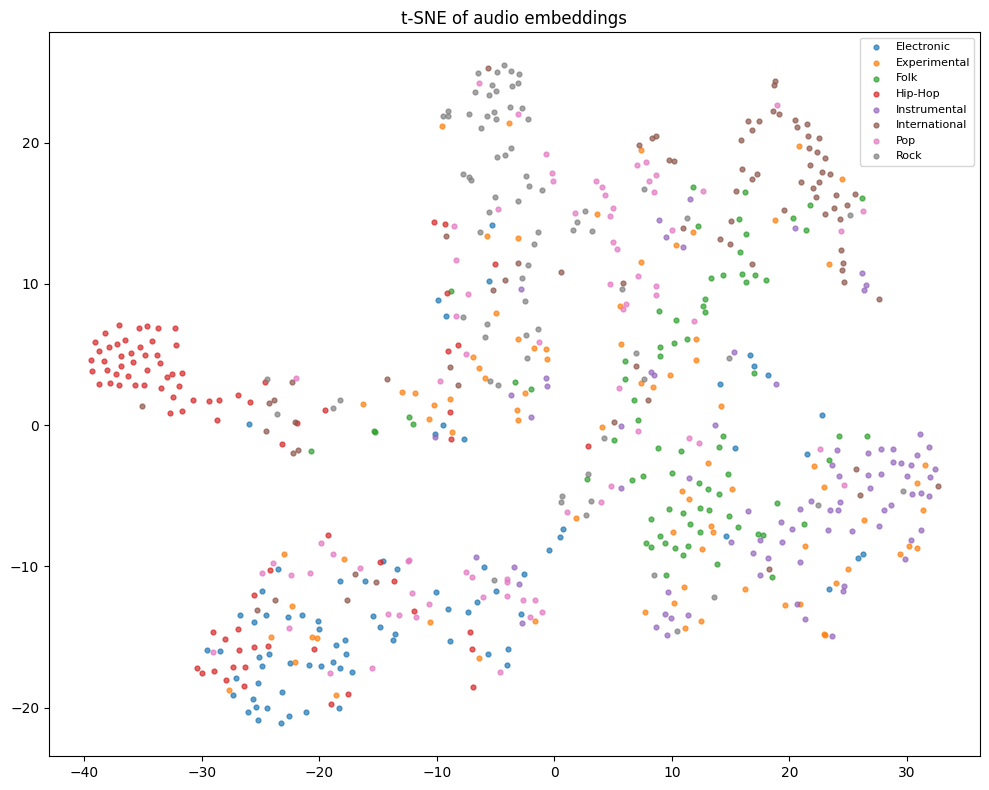

In [21]:
tsne = TSNE(n_components=2, random_state=seed, perplexity=30, init='pca')
emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
for i, genre in idx_to_label.items():
    mask = labels == i
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], s=12, alpha=0.7, label=genre)
plt.legend(loc='best', fontsize=8)
plt.title('t-SNE of audio embeddings')
plt.tight_layout()
plt.show()
